##Multimodal Transformer for Relapse-Free Survival (RFS) Prediction

## Overview

This notebook implements the complete multimodal Transformer framework developed for **Relapse-Free Survival (RFS) prediction** using the TCGA-BRCA breast cancer cohort.

The proposed model integrates three complementary patient-level data modalities:

- Clinical features
- Selected genomic features
- Histopathology feature embeddings extracted from whole-slide images (WSIs)

The objective is to learn a unified patient representation that accurately predicts relapse-free survival by combining complementary clinical, genomic, and pathology-derived information.

---

## Notebook Pipeline

This notebook performs the following steps:

1. Load the multimodal RFS training, validation, and testing datasets.
2. Load histopathology feature embeddings for each patient.
3. Prepare pathology inputs using patch sampling, zero-padding, and attention masking.
4. Build the multimodal Transformer architecture.
5. Train the model using the Cox proportional hazards survival loss.
6. Apply early stopping and save the best-performing model checkpoint.
7. Evaluate the trained model on the independent test dataset.
8. Generate multiple survival evaluation metrics and visualizations.
9. Conduct modality ablation experiments to evaluate the contribution of each data modality.

---

## Model Architecture

The proposed multimodal Transformer consists of the following components:

- Clinical Encoder
- Genomic Encoder
- Pathology Transformer Encoder
- Multimodal Fusion Module
- Survival Prediction Head

For the pathology modality, each patient is represented using deep feature embeddings extracted from histopathology image patches.

Each patient contains up to **512 pathology patch embeddings**, where each embedding has **512 dimensions**.

Patients containing more than 512 patches are randomly sampled, while patients with fewer patches are zero-padded and accompanied by an attention mask before being processed by the pathology Transformer encoder.

The outputs of the three modality encoders are fused into a shared latent representation, which is then used to estimate each patient's survival risk.

---

## Training Strategy

The model is optimized using the **Cox proportional hazards loss**, enabling direct survival prediction without transforming the task into binary classification.

Training includes:

- Adam optimizer
- Learning rate scheduling
- Gradient clipping
- Early stopping based on validation loss
- Automatic checkpoint saving of the best-performing model

---

## Model Evaluation

The trained model is evaluated using several survival analysis metrics, including:

- Concordance Index (C-index)
- Bootstrap validation with 95% confidence intervals
- Kaplan–Meier survival analysis
- Multi-group Log-rank test
- Time-dependent ROC/AUC
- Integrated Brier Score (IBS)
- Survival calibration analysis

These metrics evaluate both the discrimination ability and calibration quality of the proposed survival prediction model.

---


## Ablation Study

An ablation study is performed to quantify the contribution of each modality by evaluating the following configurations:

- Clinical only
- Genomics only
- Pathology only
- Clinical + Genomics
- Clinical + Pathology
- Genomics + Pathology
- Clinical + Genomics + Pathology (Full Multimodal Model)

The ablation experiments demonstrate the contribution of each modality and the benefit of multimodal feature fusion for relapse-free survival prediction.

---

## Outputs

This notebook generates:

- Trained multimodal Transformer model
- Best model checkpoint
- Patient-level survival risk predictions
- Performance evaluation metrics
- Kaplan–Meier survival curves
- Time-dependent ROC curves
- Survival calibration analysis
- Ablation study results
- Performance summary tables

---

## Objective

The objective of this notebook is to develop, train, and evaluate a multimodal Transformer capable of accurately predicting **Relapse-Free Survival (RFS)** by integrating clinical, genomic, and histopathology-derived information into a unified survival prediction framework.

##Imports

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
!pip install -q lifelines

import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torch.optim import AdamW

from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")

print("="*70)
print("Libraries Imported Successfully")
print("="*70)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
Libraries Imported Successfully


##Mount Google Drive

In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


##Define Project Paths

In [ ]:
# ============================================================
# PROJECT PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/TCGA_BRCA"

DATASET_DIR = os.path.join(
    BASE_DIR,
    "rfs_feature_selection"
)

PATHOLOGY_DIR = os.path.join(
    BASE_DIR,
    "Features"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "trained_models"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "transformer_results"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("="*70)
print("Project paths ready.")
print("="*70)

Project paths ready.


##Load datasets

In [ ]:
# ============================================================
# LOAD DATASETS
# ============================================================

train = pd.read_csv(
    os.path.join(
        DATASET_DIR,
       "rfs_train_selected.csv"
    )
)

validation = pd.read_csv(
    os.path.join(
        DATASET_DIR,
       "rfs_validation_selected.csv"
    )
)

test = pd.read_csv(
    os.path.join(
        DATASET_DIR,
        "rfs_test_selected.csv"
    )
)

print("="*70)
print("DATASETS LOADED")
print("="*70)

print("Train      :", train.shape)
print("Validation :", validation.shape)
print("Test       :", test.shape)

DATASETS LOADED
Train      : (249, 224)
Validation : (54, 224)
Test       : (54, 224)


In [ ]:
print("Train shape:", train.shape)

non_feature_columns = [
    "patient_id",
    "file_uuid",
    "event",
    "survival_time"
]

clinical_columns = [
    "years_to_birth",
    "Tumor_purity",
    "pathologic_stage",
    "pathology_T_stage",
    "pathology_N_stage",
    "pathology_M_stage",
    "number_of_lymph_nodes",
    "radiation_therapy"
]

clinical_columns += [
    c for c in train.columns
    if c.startswith((
        "histological_type",
        "PAM50",
        "race",
        "ethnicity"
    ))
]

genomic_columns = [
    c for c in train.columns
    if c not in clinical_columns + non_feature_columns
]

print("Clinical:", len(clinical_columns))
print("Genomic :", len(genomic_columns))

Train shape: (249, 224)
Clinical: 20
Genomic : 200


##Dataset Quality Control

In [ ]:
# ============================================================
# DATASET QUALITY CONTROL
# ============================================================

print("="*70)
print("QUALITY CONTROL")
print("="*70)

print("Training Patients :", train.patient_id.nunique())
print("Validation Patients :", validation.patient_id.nunique())
print("Testing Patients :", test.patient_id.nunique())

print()

print("Duplicate Patients")

print(train.patient_id.duplicated().sum())
print(validation.patient_id.duplicated().sum())
print(test.patient_id.duplicated().sum())

print()

print("Missing Labels")

print(train.event.isna().sum())
print(validation.event.isna().sum())
print(test.event.isna().sum())

QUALITY CONTROL
Training Patients : 249
Validation Patients : 54
Testing Patients : 54

Duplicate Patients
0
0
0

Missing Labels
0
0
0


##Set Random Seed

In [ ]:
# ============================================================
# RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

print("="*70)
print("Random Seed:", SEED)
print("="*70)

Random Seed: 42


##Device Configuration

In [ ]:
# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("="*70)
print("Running on:", DEVICE)
print("="*70)

Running on: cuda


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
# ============================================================
# INSPECT DATASET COLUMNS
# ============================================================

print("="*70)
print("TRAIN COLUMNS")
print("="*70)

for i, col in enumerate(train.columns):
    print(i, col)

TRAIN COLUMNS
0 years_to_birth
1 Tumor_purity
2 pathologic_stage
3 pathology_T_stage
4 pathology_N_stage
5 pathology_M_stage
6 number_of_lymph_nodes
7 radiation_therapy
8 histological_type_infiltratinglobularcarcinoma
9 histological_type_medullarycarcinoma
10 histological_type_metaplasticcarcinoma
11 histological_type_mixedhistology(pleasespecify)
12 histological_type_mucinouscarcinoma
13 histological_type_other,specify
14 PAM50_Her2
15 PAM50_LumA
16 PAM50_LumB
17 race_blackorafricanamerican
18 race_white
19 ethnicity_nothispanicorlatino
20 MYBPC1
21 ZNF385B
22 ALG1L
23 PCDH10
24 FLT3
25 PCDHA6
26 SPDYC
27 CACNA1H
28 PYDC1
29 TSPAN8
30 LRRN1
31 LOC100128977
32 PSCA
33 MYO3B
34 CXCL13
35 FIBCD1
36 CPA6
37 FAM5C
38 ORM1
39 HOTAIR
40 CYP4F11
41 NTRK3
42 SULT4A1
43 MMP1
44 GREB1
45 LTF
46 CEACAM6
47 PCDHA12
48 CACNG1
49 CEACAM5
50 TUBA3E
51 PCDHA13
52 HMP19
53 CACNG4
54 CYP24A1
55 CYP4F22
56 RBM24
57 LRTM2
58 NPW
59 PCDHA4
60 CYP2A6
61 GAD1
62 LOC100130148
63 MUC2
64 KCNK3
65 IL20RA
66 VTC

##Define feature groups

In [ ]:
# ============================================================
# DEFINE FEATURE GROUPS
# ============================================================


non_feature_columns = [
    "patient_id",
    "file_uuid",
    "event",
    "survival_time"
]

clinical_columns = [
    "years_to_birth",
    "Tumor_purity",
    "pathologic_stage",
    "pathology_T_stage",
    "pathology_N_stage",
    "pathology_M_stage",
    "number_of_lymph_nodes",
    "radiation_therapy"
]

clinical_columns += [
    c for c in train.columns
    if c.startswith((
        "histological_type",
        "PAM50",
        "race",
        "ethnicity"
    ))
]

genomic_columns = [
    c for c in train.columns
    if c not in clinical_columns + non_feature_columns
]

target_columns = [
    "event",
    "survival_time"
]

print("="*70)
print("FEATURE GROUPS")
print("="*70)

print("Clinical features:", len(clinical_columns))
print("Genomic features :", len(genomic_columns))

print("\nFirst clinical:")
print(clinical_columns[:5])

print("\nFirst genomic:")
print(genomic_columns[:5])

FEATURE GROUPS
Clinical features: 20
Genomic features : 200

First clinical:
['years_to_birth', 'Tumor_purity', 'pathologic_stage', 'pathology_T_stage', 'pathology_N_stage']

First genomic:
['MYBPC1', 'ZNF385B', 'ALG1L', 'PCDH10', 'FLT3']


##Create pathology loading configuration

In [ ]:
# ============================================================
# PATHOLOGY CONFIGURATION
# ============================================================


PATHOLOGY_DIR = "/content/drive/MyDrive/TCGA_BRCA/Features"


MAX_PATCHES = 512
PATCH_FEATURES = 512


print("="*70)
print("PATHOLOGY CONFIGURATION")
print("="*70)

print("Directory:")
print(PATHOLOGY_DIR)

print()

print("Maximum patches per patient:", MAX_PATCHES)
print("Patch embedding dimension:", PATCH_FEATURES)

PATHOLOGY CONFIGURATION
Directory:
/content/drive/MyDrive/TCGA_BRCA/Features

Maximum patches per patient: 512
Patch embedding dimension: 512


##Create pathology processing function

In [ ]:
# ============================================================
# PATHOLOGY PROCESSING FUNCTION
# ============================================================

import numpy as np


def load_pathology_features(
    file_uuid,
    max_patches=512
):

    path = os.path.join(
        PATHOLOGY_DIR,
        file_uuid + ".npy"
    )


    features = np.load(path)



    # -----------------------------------
    # Case 1:
    # More patches than maximum
    # -----------------------------------

    if features.shape[0] > max_patches:

        indices = np.random.choice(
            features.shape[0],
            max_patches,
            replace=False
        )

        features = features[indices]


        mask = np.ones(
            max_patches
        )



    # -----------------------------------
    # Case 2:
    # Fewer patches
    # -----------------------------------

    else:

        current = features.shape[0]


        padding = np.zeros(
            (
                max_patches-current,
                features.shape[1]
            ),
            dtype=np.float32
        )


        features = np.concatenate(
            [
                features,
                padding
            ],
            axis=0
        )


        mask = np.concatenate(
            [
                np.ones(current),
                np.zeros(max_patches-current)
            ]
        )



    return (
        features.astype(np.float32),
        mask.astype(np.float32)
    )

##Test the pathology function

In [ ]:
print(train.columns.tolist())

['years_to_birth', 'Tumor_purity', 'pathologic_stage', 'pathology_T_stage', 'pathology_N_stage', 'pathology_M_stage', 'number_of_lymph_nodes', 'radiation_therapy', 'histological_type_infiltratinglobularcarcinoma', 'histological_type_medullarycarcinoma', 'histological_type_metaplasticcarcinoma', 'histological_type_mixedhistology(pleasespecify)', 'histological_type_mucinouscarcinoma', 'histological_type_other,specify', 'PAM50_Her2', 'PAM50_LumA', 'PAM50_LumB', 'race_blackorafricanamerican', 'race_white', 'ethnicity_nothispanicorlatino', 'MYBPC1', 'ZNF385B', 'ALG1L', 'PCDH10', 'FLT3', 'PCDHA6', 'SPDYC', 'CACNA1H', 'PYDC1', 'TSPAN8', 'LRRN1', 'LOC100128977', 'PSCA', 'MYO3B', 'CXCL13', 'FIBCD1', 'CPA6', 'FAM5C', 'ORM1', 'HOTAIR', 'CYP4F11', 'NTRK3', 'SULT4A1', 'MMP1', 'GREB1', 'LTF', 'CEACAM6', 'PCDHA12', 'CACNG1', 'CEACAM5', 'TUBA3E', 'PCDHA13', 'HMP19', 'CACNG4', 'CYP24A1', 'CYP4F22', 'RBM24', 'LRTM2', 'NPW', 'PCDHA4', 'CYP2A6', 'GAD1', 'LOC100130148', 'MUC2', 'KCNK3', 'IL20RA', 'VTCN1', 

In [ ]:
# ============================================================
# TEST PATHOLOGY LOADER
# ============================================================


sample_uuid = train.iloc[0]["file_uuid"]


features, mask = load_pathology_features(
    sample_uuid
)


print("="*70)

print("Pathology feature shape:")
print(features.shape)


print()

print("Mask shape:")
print(mask.shape)


print()

print("Real patches:")
print(mask.sum())

Pathology feature shape:
(512, 512)

Mask shape:
(512,)

Real patches:
512.0


##Import PyTorch

In [ ]:
# ============================================================
# MULTIMODAL PYTORCH DATASET
# ============================================================


import torch

from torch.utils.data import Dataset


class MultimodalBreastCancerDataset(Dataset):


    def __init__(
        self,
        dataframe
    ):

        self.data = dataframe.reset_index(drop=True)



    def __len__(self):

        return len(self.data)



    def __getitem__(
        self,
        idx
    ):

        row = self.data.iloc[idx]


        # ----------------------------
        # Clinical features
        # ----------------------------

        clinical = row[
            clinical_columns
        ].values.astype(np.float32)



        # ----------------------------
        # Genomic features
        # ----------------------------

        genomic = row[
            genomic_columns
        ].values.astype(np.float32)



        # ----------------------------
        # Pathology features
        # ----------------------------

        pathology, mask = load_pathology_features(
            row["file_uuid"],
            MAX_PATCHES
        )



        # ----------------------------
        # Labels
        # ----------------------------

        event = np.float32(
            row["event"]
        )


        survival = np.float32(
            row["survival_time"]
        )



        return {

            "clinical":
            torch.tensor(
                clinical
            ),


            "genomic":
            torch.tensor(
                genomic
            ),


            "pathology":
            torch.tensor(
                pathology
            ),


            "mask":
            torch.tensor(
                mask
            ),


            "label":
            torch.tensor(
                event
            ),


            "survival":
            torch.tensor(
                survival
            ),


            "event":
torch.tensor(
    event
)
        }

##Create datasets

In [ ]:
# ============================================================
# CREATE PYTORCH DATASETS
# ============================================================


train_dataset = MultimodalBreastCancerDataset(
    train
)


val_dataset = MultimodalBreastCancerDataset(
    validation
)


test_dataset = MultimodalBreastCancerDataset(
    test
)



print("="*70)

print("Train samples:",
      len(train_dataset))

print("Validation samples:",
      len(val_dataset))

print("Test samples:",
      len(test_dataset))

Train samples: 249
Validation samples: 54
Test samples: 54


##Test one patient

In [ ]:
# ============================================================
# DATASET SAMPLE TEST
# ============================================================


sample = train_dataset[0]


print("="*70)

for key,value in sample.items():

    print(
        key,
        ":",
        value.shape
        if hasattr(value,"shape")
        else value
    )

clinical : torch.Size([20])
genomic : torch.Size([200])
pathology : torch.Size([512, 512])
mask : torch.Size([512])
label : torch.Size([])
survival : torch.Size([])
event : torch.Size([])


##Model hyperparameters

In [ ]:
# ============================================================
# MODEL CONFIGURATION
# ============================================================


MODEL_CONFIG = {


    # feature sizes

    "clinical_dim": len(clinical_columns),

    "genomic_dim": len(genomic_columns),

    "pathology_dim": 512,


    # transformer

    "embed_dim": 128,

    "num_heads": 4,

    "num_layers": 2,


    # regularization

    "dropout": 0.3,


    # training

    "batch_size": 4,

    "learning_rate": 1e-4,

    "epochs": 100

}



print("="*70)
print("MODEL CONFIGURATION")
print("="*70)


for k,v in MODEL_CONFIG.items():

    print(
        k,
        ":",
        v
    )

MODEL CONFIGURATION
clinical_dim : 20
genomic_dim : 200
pathology_dim : 512
embed_dim : 128
num_heads : 4
num_layers : 2
dropout : 0.3
batch_size : 4
learning_rate : 0.0001
epochs : 100


##Clinical Encoder

In [ ]:
# ============================================================
# CLINICAL ENCODER
# ============================================================

import torch
import torch.nn as nn



class ClinicalEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        dropout=0.3
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                embed_dim
            ),

            nn.LayerNorm(
                embed_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            )

        )



    def forward(
        self,
        x
    ):

        """
        x:
        [batch, clinical_features]

        output:
        [batch, 1, embedding]
        """


        x = self.encoder(x)


        # create token dimension

        x = x.unsqueeze(1)


        return x

##Test Clinical Encoder

In [ ]:
# ============================================================
# TEST CLINICAL ENCODER
# ============================================================


clinical_encoder = ClinicalEncoder(
    MODEL_CONFIG["clinical_dim"],
    MODEL_CONFIG["embed_dim"],
    MODEL_CONFIG["dropout"]
)



sample_clinical = torch.randn(
    4,
    MODEL_CONFIG["clinical_dim"]
)


clinical_output = clinical_encoder(
    sample_clinical
)



print(
    "Input:",
    sample_clinical.shape
)


print(
    "Output:",
    clinical_output.shape
)

Input: torch.Size([4, 20])
Output: torch.Size([4, 1, 128])


##Genomic Encoder

In [ ]:
# ============================================================
# GENOMIC ENCODER
# ============================================================


class GenomicEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        dropout=0.3
    ):

        super().__init__()



        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.LayerNorm(
                256
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),


            nn.Linear(
                256,
                embed_dim
            ),

            nn.LayerNorm(
                embed_dim
            )

        )



    def forward(
        self,
        x
    ):


        x = self.encoder(x)


        x = x.unsqueeze(1)


        return x

##Test genomic encoder

In [ ]:
# ============================================================
# TEST GENOMIC ENCODER
# ============================================================


genomic_encoder = GenomicEncoder(
    MODEL_CONFIG["genomic_dim"],
    MODEL_CONFIG["embed_dim"],
    MODEL_CONFIG["dropout"]
)



sample_genomic = torch.randn(
    4,
    MODEL_CONFIG["genomic_dim"]
)



genomic_output = genomic_encoder(
    sample_genomic
)



print(
    "Input:",
    sample_genomic.shape
)


print(
    "Output:",
    genomic_output.shape
)

Input: torch.Size([4, 200])
Output: torch.Size([4, 1, 128])


##Pathology Transformer Encoder

In [ ]:
# ============================================================
# PATHOLOGY TRANSFORMER ENCODER
# ============================================================


class PathologyEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        num_heads,
        num_layers,
        dropout=0.3
    ):

        super().__init__()


        # project pathology features
        # 512 -> 128

        self.patch_projection = nn.Linear(
            input_dim,
            embed_dim
        )



        # learnable CLS token

        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embed_dim
            )
        )



        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embed_dim,

            nhead=num_heads,

            dim_feedforward=embed_dim*4,

            dropout=dropout,

            batch_first=True,

            activation="gelu"

        )


        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers

        )



        self.norm = nn.LayerNorm(
            embed_dim
        )



    def forward(
        self,
        x,
        mask=None
    ):


        """
        x:

        [batch, patches, 512]


        output:

        [batch,1,128]

        """



        batch_size = x.size(0)



        # project patches

        x = self.patch_projection(x)


        # create CLS token for each patient

        cls_tokens = self.cls_token.expand(
            batch_size,
            -1,
            -1
        )


        x = torch.cat(
            [
                cls_tokens,
                x
            ],
            dim=1
        )



        # transformer attention

        x = self.transformer(
            x
        )



        # take CLS representation

        x = x[:,0,:]


        x = self.norm(x)


        # restore token dimension

        x = x.unsqueeze(1)



        return x

##Test Pathology Transformer Encoder

In [ ]:
# ============================================================
# TEST PATHOLOGY ENCODER
# ============================================================


pathology_encoder = PathologyEncoder(

    input_dim=MODEL_CONFIG["pathology_dim"],

    embed_dim=MODEL_CONFIG["embed_dim"],

    num_heads=MODEL_CONFIG["num_heads"],

    num_layers=MODEL_CONFIG["num_layers"],

    dropout=MODEL_CONFIG["dropout"]

)



sample_pathology = torch.randn(
    4,
    512,
    512
)



pathology_output = pathology_encoder(
    sample_pathology
)



print(
    "Input:",
    sample_pathology.shape
)


print(
    "Output:",
    pathology_output.shape
)

Input: torch.Size([4, 512, 512])
Output: torch.Size([4, 1, 128])


##The fusion module

In [ ]:
# ============================================================
# MULTIMODAL FUSION TRANSFORMER
# ============================================================


class MultimodalFusionTransformer(nn.Module):


    def __init__(
        self,
        embed_dim,
        num_heads,
        num_layers,
        dropout=0.3
    ):

        super().__init__()



        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embed_dim,

            nhead=num_heads,

            dim_feedforward=embed_dim*4,

            dropout=dropout,

            batch_first=True,

            activation="gelu"

        )



        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers

        )



        self.norm = nn.LayerNorm(
            embed_dim
        )



    def forward(
        self,
        clinical_token,
        genomic_token,
        pathology_token
    ):


        """

        Inputs:

        clinical:
        [batch,1,128]


        genomic:
        [batch,1,128]


        pathology:
        [batch,1,128]



        Output:

        fused representation

        [batch,128]

        """



        # concatenate modality tokens

        x = torch.cat(

            [
                clinical_token,
                genomic_token,
                pathology_token
            ],

            dim=1

        )



        # now:

        # [batch,3,128]


        x = self.transformer(
            x
        )


        x = self.norm(x)



        # mean pooling over modalities

        x = x.mean(
            dim=1
        )


        return x

##Testing

In [ ]:
print(MODEL_CONFIG)

{'clinical_dim': 20, 'genomic_dim': 200, 'pathology_dim': 512, 'embed_dim': 128, 'num_heads': 4, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 4, 'learning_rate': 0.0001, 'epochs': 100}


##Test the fusion module

In [ ]:
# ============================================================
# TEST FUSION TRANSFORMER
# ============================================================


fusion_model = MultimodalFusionTransformer(

    embed_dim=MODEL_CONFIG["embed_dim"],

    num_heads=MODEL_CONFIG["num_heads"],

    num_layers=MODEL_CONFIG["num_layers"],

    dropout=MODEL_CONFIG["dropout"]

)



sample_clinical_token = torch.randn(
    4,
    1,
    128
)


sample_genomic_token = torch.randn(
    4,
    1,
    128
)


sample_pathology_token = torch.randn(
    4,
    1,
    128
)



fusion_output = fusion_model(

    sample_clinical_token,

    sample_genomic_token,

    sample_pathology_token

)



print(
    "Fusion output:",
    fusion_output.shape
)

Fusion output: torch.Size([4, 128])


##Prediction Heads

In [ ]:
class SurvivalPredictionHead(nn.Module):

    def __init__(
        self,
        embed_dim,
        dropout=0.3
    ):
        super().__init__()

        self.head = nn.Sequential(

            nn.Linear(
                embed_dim,
                64
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                64,
                1
            )
        )


    def forward(self, x):

        risk = self.head(x)

        return risk

##Test Prediction Heads

In [ ]:
# ============================================================
# TEST PREDICTION HEAD
# ============================================================


prediction_head = SurvivalPredictionHead(

    embed_dim=MODEL_CONFIG["embed_dim"],

    dropout=MODEL_CONFIG["dropout"]

)



sample_features = torch.randn(
    4,
    128
)



survival_output = prediction_head(
    sample_features
)




print(
    "Survival output:",
    survival_output.shape
)

Survival output: torch.Size([4, 1])


# ============================================================
# TRAINING UTILITIES
# ============================================================

In [ ]:
# ============================================================
# DEVICE CONFIGURATION
# ============================================================

import torch

if torch.cuda.is_available():

    device = torch.device("cuda")

else:

    device = torch.device("cpu")


print("="*70)
print("DEVICE CONFIGURATION")
print("="*70)

print("Using device:", device)


if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

DEVICE CONFIGURATION
Using device: cuda
GPU: Tesla T4


##Cox Partial Likelihood Loss

In [ ]:
# ============================================================
# COX SURVIVAL LOSS
# ============================================================


class CoxPHLoss(nn.Module):


    def __init__(self):

        super().__init__()



    def forward(
        self,
        risk,
        survival_time,
        event
    ):


        """
        risk:
        predicted risk score [batch,1]

        survival_time:
        observed survival days

        event:
        1 = event occurred
        0 = censored
        """



        risk = risk.squeeze()


        survival_time = survival_time.squeeze()


        event = event.squeeze()



        # sort by decreasing survival time

        order = torch.argsort(
            survival_time,
            descending=True
        )


        risk = risk[order]

        event = event[order]



        # cumulative risk

        log_cumulative_hazard = torch.logcumsumexp(
            risk,
            dim=0
        )



        partial_likelihood = (
            risk - log_cumulative_hazard
        )



        loss = -torch.sum(
            partial_likelihood * event
        ) / (
            event.sum() + 1e-8
        )


        return loss

##Test Cox Loss

In [ ]:
# ============================================================
# TEST COX LOSS
# ============================================================


cox_loss = CoxPHLoss()



risk_test = torch.randn(
    4,
    1
)


time_test = torch.tensor(
    [1000,2000,1500,3000],
    dtype=torch.float32
)


event_test = torch.tensor(
    [1,0,1,0],
    dtype=torch.float32
)



loss_value = cox_loss(
    risk_test,
    time_test,
    event_test
)



print(
    "Cox loss:",
    loss_value.item()
)

Cox loss: 0.8862569332122803


##Create the Complete Model

In [ ]:
# ============================================================
# COMPLETE MULTIMODAL TRANSFORMER
# ============================================================


class MultimodalTransformer(nn.Module):


    def __init__(
        self,
        config
    ):

        super().__init__()



        self.clinical_encoder = ClinicalEncoder(

            config["clinical_dim"],

            config["embed_dim"],

            config["dropout"]

        )



        self.genomic_encoder = GenomicEncoder(

            config["genomic_dim"],

            config["embed_dim"],

            config["dropout"]

        )



        self.pathology_encoder = PathologyEncoder(

            config["pathology_dim"],

            config["embed_dim"],

            config["num_heads"],

            config["num_layers"],

            config["dropout"]

        )



        self.fusion = MultimodalFusionTransformer(

            config["embed_dim"],

            config["num_heads"],

            config["num_layers"],

            config["dropout"]

        )



        self.survival_head = SurvivalPredictionHead(
            config["embed_dim"],
            config["dropout"]
        )




    def forward(
        self,
        clinical,
        genomic,
        pathology,
        mask=None,
        use_modalities=None
    ):


        # ---------------------------------
        # Default: use all modalities
        # ---------------------------------

        if use_modalities is None:

            use_modalities = {

                "clinical": True,

                "genomic": True,

                "pathology": True

            }



        # ---------------------------------
        # Clinical encoder
        # ---------------------------------

        clinical_token = self.clinical_encoder(
            clinical
        )


        if not use_modalities["clinical"]:

            clinical_token = torch.zeros_like(
                clinical_token
            )



        # ---------------------------------
        # Genomic encoder
        # ---------------------------------

        genomic_token = self.genomic_encoder(
            genomic
        )


        if not use_modalities["genomic"]:

            genomic_token = torch.zeros_like(
                genomic_token
            )



        # ---------------------------------
        # Pathology encoder
        # ---------------------------------

        pathology_token = self.pathology_encoder(
            pathology,
            mask
        )


        if not use_modalities["pathology"]:

            pathology_token = torch.zeros_like(
                pathology_token
            )



        # ---------------------------------
        # Fusion Transformer
        # ---------------------------------

        fused = self.fusion(

            clinical_token,

            genomic_token,

            pathology_token

        )



        # ---------------------------------
        # Prediction heads
        # ---------------------------------

        survival = self.survival_head(fused)



        return {


            "survival":
            survival,


            "features":
            fused

        }

In [ ]:
# ============================================================
# CREATE MODEL ARCHITECTURE
# ============================================================

model = MultimodalTransformer(
    MODEL_CONFIG
)

model = model.to(device)


print("MODEL CREATED")

MODEL CREATED


##Test Complete Forward Pass

In [ ]:
# ============================================================
# MODEL FORWARD TEST
# ============================================================


sample = train_dataset[0]


clinical = sample["clinical"].unsqueeze(0).to(device)

genomic = sample["genomic"].unsqueeze(0).to(device)

pathology = sample["pathology"].unsqueeze(0).to(device)

mask = sample["mask"].unsqueeze(0).to(device)



output = model(

    clinical,

    genomic,

    pathology,

    mask

)





print(
    "Survival:",
    output["survival"].shape
)


print(
    "Features:",
    output["features"].shape
)

Survival: torch.Size([1, 1])
Features: torch.Size([1, 128])


##Create DataLoaders

In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

from torch.utils.data import DataLoader



batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


print("="*70)
print("DATALOADERS CREATED")
print("="*70)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)



DATALOADERS CREATED
Train batches: 62
Validation batches: 14
Test batches: 14


In [ ]:
batch = next(iter(train_loader))


print(batch["event"])

tensor([0., 0., 0., 0.])


##Test cells

In [ ]:
# ============================================================
# RECURRENCE CLASS DISTRIBUTION
# ============================================================


train_events = []


for batch in train_loader:

    train_events.extend(
        batch["event"].numpy()
    )


train_events = np.array(train_events)


num_negative = np.sum(train_events == 0)

num_positive = np.sum(train_events == 1)



print("="*70)
print("RECURRENCE CLASS DISTRIBUTION")
print("="*70)

print("No recurrence:", num_negative)

print("Recurrence:", num_positive)

print(
    "Total:",
    len(train_events)
)


print(
    "Positive ratio:",
    num_positive / len(train_events)
)

RECURRENCE CLASS DISTRIBUTION
No recurrence: 186
Recurrence: 62
Total: 248
Positive ratio: 0.25


In [ ]:
# ============================================================
# COMPUTE POSITIVE CLASS WEIGHT
# ============================================================


pos_weight = torch.tensor(
    num_negative / num_positive,
    dtype=torch.float32
).to(device)



print("="*70)
print("CLASS WEIGHT")
print("="*70)

print(
    "Positive class weight:",
    pos_weight.item()
)

CLASS WEIGHT
Positive class weight: 3.0


##Initialize model

In [ ]:
import inspect

print(inspect.signature(MultimodalTransformer.__init__))

(self, config)


In [ ]:
# ============================================================
# MODEL INITIALIZATION
# ============================================================

config = {

    "clinical_dim": 20,

    "genomic_dim": 200,

    "pathology_dim": 512,

    "embed_dim": 128,

    "num_heads": 4,

    "num_layers": 2,

    "dropout": 0.3

}



model = MultimodalTransformer(
    config
)


model = model.to(device)



print("="*70)
print("MODEL INITIALIZED")
print("="*70)


print(model)

MODEL INITIALIZED
MultimodalTransformer(
  (clinical_encoder): ClinicalEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=20, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
  )
  (genomic_encoder): GenomicEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=200, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (pathology_encoder): PathologyEncoder(
    (patch_projection): Linear(in_features=512, out_features=128, bias=True)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynami

In [ ]:
print(type(model))

<class '__main__.MultimodalTransformer'>


In [ ]:
dummy = next(iter(train_loader))


clinical = dummy["clinical"].to(device)
genomic = dummy["genomic"].to(device)
pathology = dummy["pathology"].to(device)
mask = dummy["mask"].to(device)


output = model(
    clinical,
    genomic,
    pathology,
    mask
)


print(output.keys())

print(

    output["survival"].shape,
    output["features"].shape
)

dict_keys(['survival', 'features'])
torch.Size([4, 1]) torch.Size([4, 128])


##Optimizer

In [ ]:
# ============================================================
# OPTIMIZER
# ============================================================


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)


print("Optimizer created")

Optimizer created


##Learning rate scheduler

In [ ]:
# ============================================================
# LR SCHEDULER
# ============================================================


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=5

)


print("Scheduler created")

Scheduler created


##Test cell

In [ ]:
batch = next(iter(train_loader))

print(batch.keys())

print("label:", batch["label"].shape)
print("survival:", batch["survival"].shape)
print("event:", batch["event"].shape)

dict_keys(['clinical', 'genomic', 'pathology', 'mask', 'label', 'survival', 'event'])
label: torch.Size([4])
survival: torch.Size([4])
event: torch.Size([4])


##Training function

In [ ]:
# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    total_loss = 0


    for batch in loader:

        clinical = batch["clinical"].to(device)
        genomic = batch["genomic"].to(device)
        pathology = batch["pathology"].to(device)
        mask = batch["mask"].to(device)

        survival = batch["survival"].float().to(device)
        event = batch["event"].float().to(device)


        optimizer.zero_grad()


        output = model(
            clinical,
            genomic,
            pathology,
            mask,
            use_modalities={
                "clinical": True,
                "genomic": True,
                "pathology": True
            }
        )


        survival_pred = output["survival"]

        survival_pred = survival_pred.view(-1)


        loss = cox_loss(
            survival_pred,
            survival,
            event
        )


        print(
            f"Survival Loss={loss.item():.4f}"
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        optimizer.step()


        total_loss += loss.item()


    return total_loss / len(loader)

##Validation function

In [ ]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_epoch(
    model,
    loader
):

    model.eval()

    total_loss = 0

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:

            clinical = batch["clinical"].to(device)
            genomic = batch["genomic"].to(device)
            pathology = batch["pathology"].to(device)
            mask = batch["mask"].to(device)

            survival = batch["survival"].float().to(device)
            event = batch["event"].float().to(device)


            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities={
                    "clinical": True,
                    "genomic": True,
                    "pathology": True
                }
            )


            survival_pred = output["survival"]

            survival_pred = survival_pred.view(-1)


            loss = cox_loss(
                survival_pred,
                survival,
                event
            )


            total_loss += loss.item()


            all_risk.extend(
                survival_pred.cpu().numpy()
            )

            all_survival.extend(
                survival.cpu().numpy()
            )

            all_events.extend(
                event.cpu().numpy()
            )


    return (
        total_loss / len(loader),
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )

##Early stopping class

In [ ]:
# ============================================================
# EARLY STOPPING
# ============================================================

import copy


class EarlyStopping:


    def __init__(
        self,
        patience=15
    ):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.best_model = None



    def __call__(
        self,
        loss,
        model
    ):


        if loss < self.best_loss:


            self.best_loss = loss

            self.counter = 0

            self.best_model = copy.deepcopy(
                model.state_dict()
            )


        else:

            self.counter += 1



        if self.counter >= self.patience:

            return True


        return False



    def restore_best_weights(
        self,
        model
    ):

        model.load_state_dict(
            self.best_model
        )

##The full training loop

In [ ]:
# ============================================================
# FULL TRAINING LOOP
# ============================================================


import os
import torch


EPOCHS = 100


checkpoint_path = "/content/drive/MyDrive/TCGA_BRCA/trained_models/best_transformer_all_Modailates_RFS2.pt"


early_stopping = EarlyStopping(
    patience=15
)



history = {

    "train_loss": [],

    "val_loss": []

}



print("="*70)
print("START TRAINING")
print("="*70)



for epoch in range(1, EPOCHS + 1):


    print(f"\nEpoch {epoch}/{EPOCHS}")



    # ----------------------------
    # Training
    # ----------------------------

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer
    )



    # ----------------------------
    # Validation
    # ----------------------------


    val_loss, val_risk, val_survival, val_events = validate_epoch(
        model,
        val_loader
    )

    history["train_loss"].append(
        train_loss
    )


    history["val_loss"].append(
        val_loss
    )



    # ----------------------------
    # Scheduler
    # ----------------------------

    scheduler.step(
        val_loss
    )



    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )



    # ----------------------------
    # Save best model
    # ----------------------------

    if val_loss < early_stopping.best_loss:


        torch.save(
            model.state_dict(),
            checkpoint_path
        )


        print(
            "✓ Best model saved"
        )



    # ----------------------------
    # Early stopping
    # ----------------------------

    stop = early_stopping(
        val_loss,
        model
    )



    if stop:


        print(
            "Early stopping triggered"
        )

        break



print("\n")
print("="*70)
print("TRAINING FINISHED")
print("="*70)


print(
    "Best validation loss:",
    early_stopping.best_loss
)


print(
    "Saved checkpoint:",
    checkpoint_path
)

START TRAINING

Epoch 1/100
Survival Loss=0.6021
Survival Loss=-0.0000
Survival Loss=0.9851
Survival Loss=1.1042
Survival Loss=-0.0000
Survival Loss=0.5772
Survival Loss=1.0374
Survival Loss=0.6898
Survival Loss=-0.0000
Survival Loss=1.5225
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=0.9882
Survival Loss=0.7440
Survival Loss=0.3935
Survival Loss=-0.0000
Survival Loss=1.2406
Survival Loss=-0.0000
Survival Loss=0.7317
Survival Loss=1.1114
Survival Loss=0.6909
Survival Loss=1.1185
Survival Loss=-0.0000
Survival Loss=0.3112
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=1.4349
Survival Loss=1.4510
Survival Loss=-0.0000
Survival Loss=0.5568
Survival Loss=0.6670
Survival Loss=0.6768
Survival Loss=-0.0000
Survival Loss=0.5238
Survival Loss=-0.0000
Survival Loss=0.8639
Survival Loss=-0.0000
Survival Loss=1.4949
Survival Loss=-0.0000
Survival Loss=-0.0000
Survival Loss=0.6787
Surviva

##Load best model

In [ ]:


# ============================================================
# LOAD YESTERDAY BEST MODEL CHECKPOINT
# ============================================================


checkpoint_path = "/content/drive/MyDrive/TCGA_BRCA/trained_models/best_transformer_all_Modailates_RFS2.pt"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)


model.eval()


print("="*70)
print("YESTERDAY MODEL LOADED")
print("="*70)

YESTERDAY MODEL LOADED


##Ablation experiment

In [ ]:
# ============================================================
# ABLATION STUDY INFERENCE FUNCTION
# ============================================================


import numpy as np
import torch


def predict_survival_ablation(
    model,
    loader,
    use_modalities
):

    model.eval()

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:


            clinical = batch["clinical"].to(device)

            genomic = batch["genomic"].to(device)

            pathology = batch["pathology"].to(device)

            mask = batch["mask"].to(device)


            survival = batch["survival"].cpu().numpy()

            event = batch["event"].cpu().numpy()



            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities=use_modalities
            )


            risk = output["survival"]


            all_risk.extend(
                risk.view(-1)
                .cpu()
                .numpy()
            )


            all_survival.extend(
                survival
            )


            all_events.extend(
                event
            )


    return (
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )

In [ ]:
# ============================================================
# ABLATION CONFIGURATIONS
# ============================================================


ablation_configs = {


    "Clinical only":
    {
        "clinical": True,
        "genomic": False,
        "pathology": False
    },


    "Genomics only":
    {
        "clinical": False,
        "genomic": True,
        "pathology": False
    },


    "Pathology only":
    {
        "clinical": False,
        "genomic": False,
        "pathology": True
    },


    "Clinical + Genomics":
    {
        "clinical": True,
        "genomic": True,
        "pathology": False
    },


    "Clinical + Pathology":
    {
        "clinical": True,
        "genomic": False,
        "pathology": True
    },


    "Genomics + Pathology":
    {
        "clinical": False,
        "genomic": True,
        "pathology": True
    },


    "All modalities":
    {
        "clinical": True,
        "genomic": True,
        "pathology": True
    }

}

In [ ]:
# ============================================================
# ABLATION STUDY C-INDEX RESULTS
# ============================================================


from lifelines.utils import concordance_index
import pandas as pd



ablation_results = []



for name, modalities in ablation_configs.items():


    print("="*70)
    print(name)
    print("="*70)



    risk, survival, events = predict_survival_ablation(
        model,
        test_loader,
        modalities
    )



    c_index = concordance_index(
        survival,
        -risk,
        events
    )


    print(
        "C-index:",
        round(c_index,4)
    )



    ablation_results.append(
        [
            name,
            c_index
        ]
    )



ablation_df = pd.DataFrame(
    ablation_results,
    columns=[
        "Model",
        "C-index"
    ]
)



print("\nFINAL ABLATION TABLE")

display(
    ablation_df.sort_values(
        "C-index",
        ascending=False
    )
)

Clinical only
C-index: 0.5886
Genomics only
C-index: 0.7911
Pathology only
C-index: 0.5918
Clinical + Genomics
C-index: 0.8101
Clinical + Pathology
C-index: 0.6741
Genomics + Pathology
C-index: 0.8133
All modalities
C-index: 0.8354

FINAL ABLATION TABLE


,Model,C-index
6,All modalities,0.835443
5,Genomics + Pathology,0.813291
3,Clinical + Genomics,0.810127
1,Genomics only,0.791139
4,Clinical + Pathology,0.674051
2,Pathology only,0.591772
0,Clinical only,0.588608


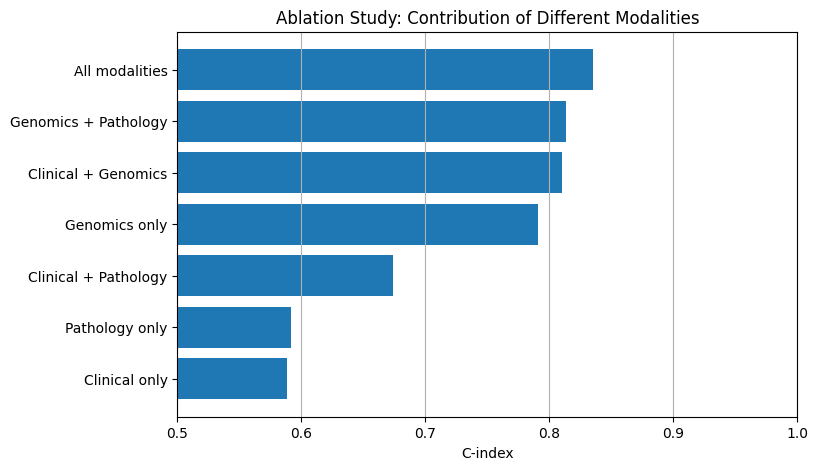

In [ ]:
import matplotlib.pyplot as plt


plot_df = ablation_df.sort_values(
    "C-index",
    ascending=True
)


plt.figure(figsize=(8,5))


plt.barh(
    plot_df["Model"],
    plot_df["C-index"]
)


plt.xlabel(
    "C-index"
)


plt.title(
    "Ablation Study: Contribution of Different Modalities"
)


plt.xlim(
    0.5,
    1.0
)


plt.grid(
    axis="x"
)


plt.show()

##Test inference

In [ ]:
# ============================================================
# TEST INFERENCE (RFS ONLY)
# ============================================================


def predict_test_rfs(
    model,
    loader,
    use_modalities=None
):

    model.eval()

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:


            clinical = batch["clinical"].to(device)

            genomic = batch["genomic"].to(device)

            pathology = batch["pathology"].to(device)

            mask = batch["mask"].to(device)


            survival = batch["survival"].float().to(device)

            event = batch["event"].float().to(device)



            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities=use_modalities
            )


            # only survival output exists now
            risk = output["survival"]


            risk = risk.view(-1)


            all_risk.extend(
                risk.cpu().numpy()
            )


            all_survival.extend(
                survival.cpu().numpy()
            )


            all_events.extend(
                event.cpu().numpy()
            )



    return (
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )

In [ ]:
test_risk, test_survival, test_events = predict_test_rfs(
    model,
    test_loader,
    {
        "clinical": True,
        "genomic": True,
        "pathology": True
    }
)


print("="*70)
print("TEST RFS PREDICTION COMPLETE")
print("="*70)

print("Risk:", test_risk.shape)
print("Survival:", test_survival.shape)
print("Events:", test_events.shape)

TEST RFS PREDICTION COMPLETE
Risk: (54,)
Survival: (54,)
Events: (54,)


##Validation inference

In [ ]:
# ============================================================
# VALIDATION INFERENCE (RFS)
# ============================================================


def predict_validation(
    model,
    loader,
    use_modalities=None
):

    model.eval()

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:


            clinical = batch["clinical"].to(device)

            genomic = batch["genomic"].to(device)

            pathology = batch["pathology"].to(device)

            mask = batch["mask"].to(device)


            survival_time = batch["survival"].float().to(device)

            event = batch["event"].float().to(device)



            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities=use_modalities
            )


            survival_pred = output["survival"]


            survival_pred = survival_pred.view(-1)


            all_risk.extend(
                survival_pred.cpu().numpy()
            )


            all_survival.extend(
                survival_time.cpu().numpy()
            )


            all_events.extend(
                event.cpu().numpy()
            )



    return (
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )



val_risk, val_survival, val_events = predict_validation(
    model,
    val_loader,
    {
        "clinical": True,
        "genomic": True,
        "pathology": True
    }
)



print("="*70)
print("VALIDATION RFS PREDICTION COMPLETE")
print("="*70)


print(
    "Validation risk:",
    val_risk.shape
)


print(
    "Validation survival:",
    val_survival.shape
)


print(
    "Validation events:",
    val_events.shape
)

VALIDATION RFS PREDICTION COMPLETE
Validation risk: (54,)
Validation survival: (54,)
Validation events: (54,)


##Evaluation Metrics

##Survival evaluation (C-index)

In [ ]:
# ============================================================
# VALIDATION SURVIVAL INFERENCE
# ============================================================


def predict_validation(
    model,
    loader,
    use_modalities=None
):

    model.eval()

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:


            clinical = batch["clinical"].to(device)

            genomic = batch["genomic"].to(device)

            pathology = batch["pathology"].to(device)

            mask = batch["mask"].to(device)


            survival = batch["survival"].numpy()
            event = batch["event"].numpy()



            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities=use_modalities
            )


            risk = output["survival"]


            all_risk.extend(
                risk.view(-1)
                .cpu()
                .numpy()
            )


            all_survival.extend(
                survival
            )


            all_events.extend(
                event
            )


    return (
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )


In [ ]:
val_risk, val_survival, val_events = predict_validation(
    model,
    val_loader,
    {
        "clinical": True,
        "genomic": True,
        "pathology": True
    }
)


print(val_risk.shape)
print(val_survival.shape)
print(val_events.shape)

(54,)
(54,)
(54,)


In [ ]:
# ============================================================
# TEST SURVIVAL INFERENCE
# ============================================================


def predict_test_survival(
    model,
    loader,
    use_modalities=None
):

    model.eval()

    all_risk = []
    all_survival = []
    all_events = []


    with torch.no_grad():

        for batch in loader:


            clinical = batch["clinical"].to(device)

            genomic = batch["genomic"].to(device)

            pathology = batch["pathology"].to(device)

            mask = batch["mask"].to(device)



            survival = batch["survival"].cpu().numpy()

            event = batch["event"].cpu().numpy()



            output = model(
                clinical,
                genomic,
                pathology,
                mask,
                use_modalities=use_modalities
            )


            risk = output["survival"]


            all_risk.extend(
                risk.view(-1)
                .cpu()
                .numpy()
            )


            all_survival.extend(
                survival
            )


            all_events.extend(
                event
            )


    return (
        np.array(all_risk),
        np.array(all_survival),
        np.array(all_events)
    )

In [ ]:
test_risk, test_survival, test_events = predict_test_survival(
    model,
    test_loader,
    {
        "clinical": True,
        "genomic": True,
        "pathology": True
    }
)

In [ ]:
# ============================================================
# BOOTSTRAP 95% CI FOR C-INDEX
# ============================================================

!pip install -q lifelines

from lifelines.utils import concordance_index
import numpy as np

N_BOOTSTRAPS = 1000

boot_scores = []

rng = np.random.RandomState(42)

n = len(test_survival)

for _ in range(N_BOOTSTRAPS):

    indices = rng.choice(
        n,
        size=n,
        replace=True
    )

    c = concordance_index(
        test_survival[indices],
        -test_risk[indices],
        test_events[indices]
    )

    boot_scores.append(c)

boot_scores = np.array(boot_scores)

ci_lower = np.percentile(
    boot_scores,
    2.5
)

ci_upper = np.percentile(
    boot_scores,
    97.5
)

print("="*70)
print("BOOTSTRAP C-INDEX")
print("="*70)

print(f"Mean      : {boot_scores.mean():.4f}")
print(f"Std       : {boot_scores.std():.4f}")
print(f"95% CI    : ({ci_lower:.4f}, {ci_upper:.4f})")

BOOTSTRAP C-INDEX
Mean      : 0.8330
Std       : 0.0639
95% CI    : (0.6913, 0.9388)


In [ ]:
from lifelines.utils import concordance_index


c_index = concordance_index(
    test_survival,
    -test_risk,
    test_events
)


print("="*70)
print("RFS PERFORMANCE")
print("="*70)

print(
    f"C-index: {c_index:.4f}"
    f"(95% CI {ci_lower:.4f}-{ci_upper:.4f})"
)

RFS PERFORMANCE
C-index: 0.8354(95% CI 0.6913-0.9388)


##Kaplan-Meier risk groups

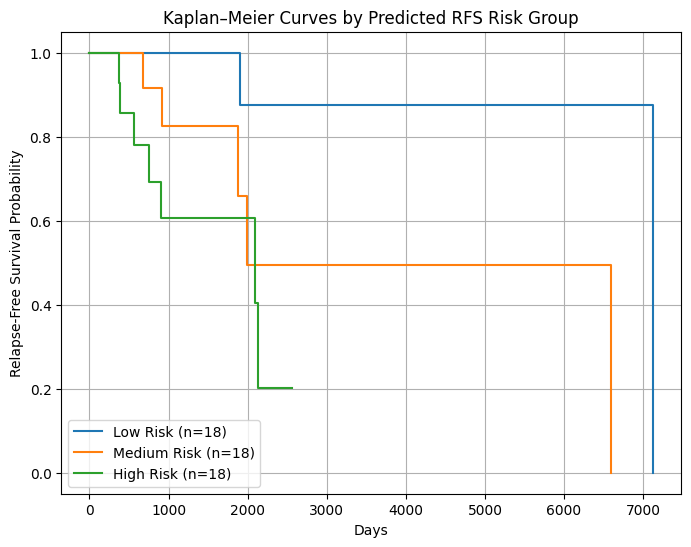

MULTI-GROUP LOG-RANK TEST
p-value: 0.005918811983336525


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import numpy as np
import matplotlib.pyplot as plt


# median_risk = np.median(test_risk)


# high_risk = test_risk >= median_risk
# low_risk = test_risk < median_risk

q1 = np.percentile(test_risk, 33.33)
q2 = np.percentile(test_risk, 66.67)

low_risk = test_risk <= q1

medium_risk = (test_risk > q1) & (test_risk <= q2)

high_risk = test_risk > q2



from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

kmf.fit(
    test_survival[low_risk],
    test_events[low_risk],
    label=f"Low Risk (n={low_risk.sum()})"
)
kmf.plot(ci_show=False)

kmf.fit(
    test_survival[medium_risk],
    test_events[medium_risk],
    label=f"Medium Risk (n={medium_risk.sum()})"
)
kmf.plot(ci_show=False)

kmf.fit(
    test_survival[high_risk],
    test_events[high_risk],
    label=f"High Risk (n={high_risk.sum()})"
)
kmf.plot(ci_show=False)

plt.title("Kaplan–Meier Curves by Predicted RFS Risk Group")

plt.xlabel("Days")

plt.ylabel("Relapse-Free Survival Probability")

plt.grid(True)

plt.show()

from lifelines.statistics import multivariate_logrank_test

result = multivariate_logrank_test(
    test_survival,
    np.select(
        [low_risk, medium_risk, high_risk],
        [0, 1, 2]
    ),
    test_events
)

print("="*70)
print("MULTI-GROUP LOG-RANK TEST")
print("="*70)

print("p-value:", result.p_value)

##Time-dependent AUC

In [ ]:
print("Maximum survival time:", test_survival.max())
print("Minimum survival time:", test_survival.min())

print("Years:")
print(test_survival.max()/365)

Maximum survival time: 7126.0
Minimum survival time: 10.0
Years:
19.523287


In [ ]:
# ============================================================
# CREATE SURVIVAL OBJECT FOR scikit-survival
# ============================================================
!pip install scikit-survival
from sksurv.util import Surv


y_test = Surv.from_arrays(
    event=test_events.astype(bool),
    time=test_survival
)


print("="*70)
print("SURVIVAL OBJECT CREATED")
print("="*70)

print(y_test[:5])

SURVIVAL OBJECT CREATED
[(False, 1013.) (False, 2372.) ( True, 1993.) ( True, 6593.)
 (False,  528.)]


In [ ]:
# ============================================================
# DEFINE EVALUATION TIMES
# ============================================================

import numpy as np


evaluation_times = np.array(
    [
        3*365,      # 3 years
        5*365,      # 5 years
        10*365      # 10 years
    ]
)


print("="*70)
print("AUC EVALUATION TIMES")
print("="*70)

for t in evaluation_times:
    print(f"{t} days ({t/365:.0f} years)")

AUC EVALUATION TIMES
1095 days (3 years)
1825 days (5 years)
3650 days (10 years)


In [ ]:
# ============================================================
# TIME-DEPENDENT AUC
# ============================================================

!pip install scikit-survival

from sksurv.metrics import cumulative_dynamic_auc


auc_values, mean_auc = cumulative_dynamic_auc(
    y_test,
    y_test,
    test_risk,
    evaluation_times
)


print("="*70)
print("TIME-DEPENDENT AUC")
print("="*70)


for t, auc in zip(
    evaluation_times,
    auc_values
):

    print(
        f"{t/365:.0f} years AUC: {auc:.4f}"
    )


print(
    "\nMean AUC:",
    mean_auc
)

TIME-DEPENDENT AUC
3 years AUC: 0.9111
5 years AUC: 0.8872
10 years AUC: 0.8039

Mean AUC: 0.8480786585465601


##Integrated Brier Score (IBS)

In [ ]:
# ============================================================
# INTEGRATED BRIER SCORE (IBS)
# ============================================================

from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np

# --------------------------------------------------
# Estimate censoring distribution
# --------------------------------------------------

times = np.percentile(
    test_survival,
    np.linspace(10, 90, 100)
)

# --------------------------------------------------
# Convert risk scores to survival probabilities
# --------------------------------------------------
# Temporary approximation:
# higher risk -> lower survival probability

survival_prob = np.exp(
    -np.outer(
        np.exp(test_risk),
        times / times.max()
    )
)

ibs = integrated_brier_score(
    y_test,
    y_test,
    survival_prob,
    times
)

print("="*70)
print("INTEGRATED BRIER SCORE")
print("="*70)
print(f"IBS = {ibs:.4f}")

INTEGRATED BRIER SCORE
IBS = 0.1350


##Survival Calibration Curve

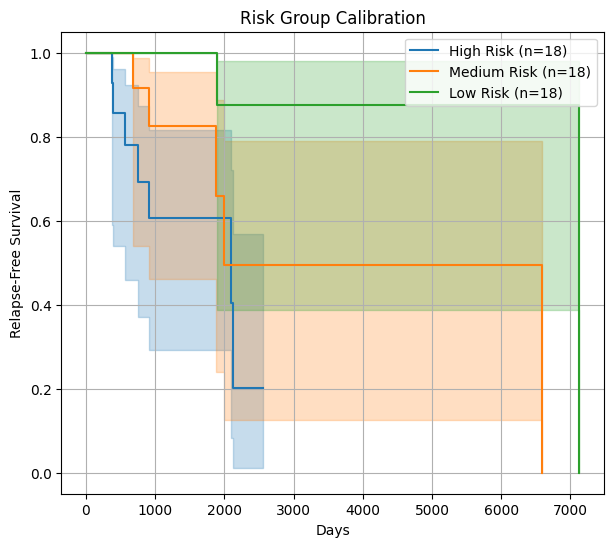

In [ ]:
# ============================================================
# SURVIVAL CALIBRATION (RISK GROUPS)
# ============================================================

import pandas as pd

risk_df = pd.DataFrame({
    "risk": test_risk,
    "time": test_survival,
    "event": test_events
})

risk_df["group"] = pd.qcut(
    risk_df["risk"],
    q=3,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.figure(figsize=(7,6))

for group in risk_df["group"].unique():

    subset = risk_df[
        risk_df["group"] == group
    ]

    kmf = KaplanMeierFitter()

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"{group} (n={len(subset)})"
    )

    kmf.plot()

plt.title("Risk Group Calibration")
plt.xlabel("Days")
plt.ylabel("Relapse-Free Survival")
plt.grid(True)
plt.show()

##Investigation cells

In [ ]:
# ============================================================
# COMBINE ALL SPLITS FOR INVESTIGATION
# ============================================================

df_all = pd.concat(
    [train, validation, test],
    axis=0,
    ignore_index=True
)

print("Combined dataframe shape:", df_all.shape)
print("Total patients:", len(df_all))

Combined dataframe shape: (357, 224)
Total patients: 357


##Investigation 1 — Check the pathology branch

In [ ]:
# ============================================================
# PATCH STATISTICS
# ============================================================

patch_counts = []

for uuid in df_all["file_uuid"]:

    pathology, mask = load_pathology_features(
        uuid,
        MAX_PATCHES
    )

    patch_counts.append(mask.sum())

patch_counts = np.array(patch_counts)

print("="*70)
print("PATCH STATISTICS")
print("="*70)

print("MAX_PATCHES =", MAX_PATCHES)

print("Minimum patches :", patch_counts.min())
print("Maximum patches :", patch_counts.max())
print("Average patches :", patch_counts.mean())
print("Median patches  :", np.median(patch_counts))

print()
print("Patients using ALL patches:",
      np.sum(patch_counts == MAX_PATCHES))

print("Patients with fewer patches:",
      np.sum(patch_counts < MAX_PATCHES))

PATCH STATISTICS
MAX_PATCHES = 512
Minimum patches : 9.0
Maximum patches : 512.0
Average patches : 501.36414
Median patches  : 512.0

Patients using ALL patches: 339
Patients with fewer patches: 18


##Investigation 2 — Verify recurrence labels

In [ ]:
# ============================================================
# LABEL CHECK
# ============================================================

print("="*70)
print("RECURRENCE LABEL CHECK")
print("="*70)

print(df_all["event"].value_counts(dropna=False))

print()

print("Missing labels:",
      df_all["event"].isna().sum())

print()

print("Unique labels:",
      df_all["event"].unique())

RECURRENCE LABEL CHECK
event
0    266
1     91
Name: count, dtype: int64

Missing labels: 0

Unique labels: [1 0]


##Investigation 3 — Survival statistics

In [ ]:
# ============================================================
# SURVIVAL STATISTICS
# ============================================================

print("="*70)
print("SURVIVAL STATISTICS")
print("="*70)

print(df_all["survival_time"].describe())

print()

print("Minimum:",
      df_all["survival_time"].min())

print("Maximum:",
      df_all["survival_time"].max())

print()

print("Number of censored:",
      (df_all["event"]==0).sum())

print("Number of events:",
      (df_all["event"]==1).sum())

SURVIVAL STATISTICS
count     357.000000
mean     1288.647059
std      1372.999560
min         1.000000
25%       408.000000
50%       821.000000
75%      1692.000000
max      8556.000000
Name: survival_time, dtype: float64

Minimum: 1.0
Maximum: 8556.0

Number of censored: 266
Number of events: 91


##Investigation 5 — Check prediction probabilities

PREDICTION DISTRIBUTION
Minimum probability: 0.23071307
Maximum probability: 0.6684415
Mean probability: 0.43150553
Median probability: 0.42414784


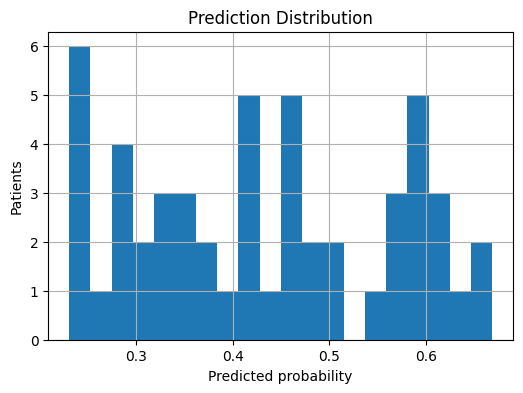

In [ ]:
# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

print("="*70)
print("PREDICTION DISTRIBUTION")
print("="*70)

print("Minimum probability:",
      test_probs.min())

print("Maximum probability:",
      test_probs.max())

print("Mean probability:",
      test_probs.mean())

print("Median probability:",
      np.median(test_probs))

# Histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    test_probs,
    bins=20
)

plt.xlabel("Predicted probability")
plt.ylabel("Patients")

plt.title("Prediction Distribution")

plt.grid()

plt.show()

##Checking the data again for the RFS and DFS (more confirmation)

In [ ]:
import pandas as pd
import os


# ============================================================
# PATHS
# ============================================================

FOLLOW_UP_PATH = "/content/drive/MyDrive/BreastCanser-DataSet/follow_up.tsv"

CLINICAL_PATH = "/content/drive/MyDrive/BreastCanser-DataSet/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsv"



# ============================================================
# LOAD DATA
# ============================================================

follow_up = pd.read_csv(
    FOLLOW_UP_PATH,
    sep="\t",
    low_memory=False
)


clinical = pd.read_csv(
    CLINICAL_PATH,
    sep="\t",
    low_memory=False
)



print("="*70)
print("FILES LOADED")
print("="*70)


print("Follow-up shape:")
print(follow_up.shape)


print("\nClinical shape:")
print(clinical.shape)

FILES LOADED
Follow-up shape:
(9427, 152)

Clinical shape:
(20, 1098)


In [ ]:
print("="*70)
print("FOLLOW UP COLUMNS")
print("="*70)

for i, col in enumerate(follow_up.columns):
    print(i, col)



print("\n")


print("="*70)
print("CLINICAL COLUMNS")
print("="*70)

for i, col in enumerate(clinical.columns):
    print(i, col)

FOLLOW UP COLUMNS
0 project.project_id
1 cases.case_id
2 cases.submitter_id
3 follow_ups.adverse_event
4 follow_ups.adverse_event_grade
5 follow_ups.barretts_esophagus_goblet_cells_present
6 follow_ups.cause_of_response
7 follow_ups.days_to_adverse_event
8 follow_ups.days_to_first_event
9 follow_ups.days_to_follow_up
10 follow_ups.days_to_imaging
11 follow_ups.days_to_progression
12 follow_ups.days_to_progression_free
13 follow_ups.days_to_recurrence
14 follow_ups.discontiguous_lesion_count
15 follow_ups.disease_response
16 follow_ups.ecog_performance_status
17 follow_ups.evidence_of_progression_type
18 follow_ups.evidence_of_recurrence_type
19 follow_ups.first_event
20 follow_ups.follow_up_id
21 follow_ups.histologic_progression
22 follow_ups.history_of_tumor
23 follow_ups.history_of_tumor_type
24 follow_ups.hormone_replacement_therapy_type
25 follow_ups.imaging_anatomic_site
26 follow_ups.imaging_findings
27 follow_ups.imaging_result
28 follow_ups.imaging_suv
29 follow_ups.imaging_su

In [ ]:
keywords = [
    "recurr",
    "progress",
    "disease",
    "event",
    "survival",
    "death",
    "follow",
    "new",
    "relapse"
]


print("="*70)
print("FOLLOW UP RELEVANT COLUMNS")
print("="*70)


for col in follow_up.columns:

    if any(k in col.lower() for k in keywords):
        print(col)



print("\n")


print("="*70)
print("CLINICAL RELEVANT COLUMNS")
print("="*70)


for col in clinical.columns:

    if any(k in col.lower() for k in keywords):
        print(col)

FOLLOW UP RELEVANT COLUMNS
follow_ups.adverse_event
follow_ups.adverse_event_grade
follow_ups.barretts_esophagus_goblet_cells_present
follow_ups.cause_of_response
follow_ups.days_to_adverse_event
follow_ups.days_to_first_event
follow_ups.days_to_follow_up
follow_ups.days_to_imaging
follow_ups.days_to_progression
follow_ups.days_to_progression_free
follow_ups.days_to_recurrence
follow_ups.discontiguous_lesion_count
follow_ups.disease_response
follow_ups.ecog_performance_status
follow_ups.evidence_of_progression_type
follow_ups.evidence_of_recurrence_type
follow_ups.first_event
follow_ups.follow_up_id
follow_ups.histologic_progression
follow_ups.history_of_tumor
follow_ups.history_of_tumor_type
follow_ups.hormone_replacement_therapy_type
follow_ups.imaging_anatomic_site
follow_ups.imaging_findings
follow_ups.imaging_result
follow_ups.imaging_suv
follow_ups.imaging_suv_max
follow_ups.imaging_type
follow_ups.karnofsky_performance_status
follow_ups.peritoneal_washing_results
follow_ups.proc

In [ ]:
rec_cols = [
    c for c in follow_up.columns
    if "recurr" in c.lower()
]


print("Recurrence columns:")
print(rec_cols)


if len(rec_cols) > 0:

    for c in rec_cols:

        print("\nCOLUMN:", c)
        print(
            follow_up[c].value_counts(dropna=False).head(20)
        )

Recurrence columns:
['follow_ups.days_to_recurrence', 'follow_ups.evidence_of_recurrence_type', 'follow_ups.progression_or_recurrence', 'follow_ups.progression_or_recurrence_anatomic_site', 'follow_ups.progression_or_recurrence_type']

COLUMN: follow_ups.days_to_recurrence
follow_ups.days_to_recurrence
'--     9398
596        2
136        1
181        1
155        1
301        1
746        1
1516       1
2330       1
1645       1
648        1
1034       1
3287       1
431        1
756        1
966        1
667        1
419        1
1709       1
2989       1
Name: count, dtype: int64

COLUMN: follow_ups.evidence_of_recurrence_type
follow_ups.evidence_of_recurrence_type
'--    9427
Name: count, dtype: int64

COLUMN: follow_ups.progression_or_recurrence
follow_ups.progression_or_recurrence
'--    9286
Yes     141
Name: count, dtype: int64

COLUMN: follow_ups.progression_or_recurrence_anatomic_site
follow_ups.progression_or_recurrence_anatomic_site
'--                                      

In [ ]:
surv_cols = [
    c for c in clinical.columns
    if (
        "death" in c.lower()
        or "last" in c.lower()
        or "follow" in c.lower()
        or "survival" in c.lower()
    )
]


print("="*70)
print("SURVIVAL RELATED COLUMNS")
print("="*70)


for c in surv_cols:
    print(c)

SURVIVAL RELATED COLUMNS


In [ ]:
surv_cols = [
    c for c in clinical.columns
    if (
        "death" in c.lower()
        or "last" in c.lower()
        or "follow" in c.lower()
        or "survival" in c.lower()
    )
]


print("="*70)
print("SURVIVAL RELATED COLUMNS")
print("="*70)


for c in surv_cols:
    print(c)

SURVIVAL RELATED COLUMNS


In [ ]:
print("="*70)
print("FOLLOW UP SAMPLE")
print("="*70)

display(
    follow_up.head()
)

FOLLOW UP SAMPLE


,project.project_id,cases.case_id,cases.submitter_id,follow_ups.adverse_event,follow_ups.adverse_event_grade,follow_ups.barretts_esophagus_goblet_cells_present,follow_ups.cause_of_response,follow_ups.days_to_adverse_event,follow_ups.days_to_first_event,follow_ups.days_to_follow_up,...,other_clinical_attributes.undescended_testis_corrected,other_clinical_attributes.undescended_testis_corrected_age,other_clinical_attributes.undescended_testis_corrected_age_range,other_clinical_attributes.undescended_testis_corrected_laterality,other_clinical_attributes.undescended_testis_corrected_method,other_clinical_attributes.undescended_testis_history,other_clinical_attributes.undescended_testis_history_laterality,other_clinical_attributes.viral_hepatitis_serology_tests,other_clinical_attributes.weeks_gestation_at_birth,other_clinical_attributes.weight
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,'--,'--,'--,'--,'--,'--,337,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,'--,'--,'--,'--,'--,'--,127,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,'--,'--,'--,'--,'--,'--,337,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
3,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
4,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--


In [ ]:
print("="*70)
print("UNIQUE PATIENTS")
print("="*70)


for name, df in [
    ("Clinical", clinical),
    ("Follow-up", follow_up)
]:

    possible = [
        c for c in df.columns
        if "barcode" in c.lower()
        or "patient" in c.lower()
    ]

    print("\n", name)
    print(possible)

UNIQUE PATIENTS

 Clinical
[]

 Follow-up
[]


In [ ]:
import pandas as pd
import numpy as np

# replace with your dataframe names if different
fu = follow_up.copy()

patient_col = "cases.submitter_id"


# convert '--' to missing
fu = fu.replace("--", np.nan)


print("="*70)
print("PATIENT COUNT")
print("="*70)

print("Unique patients:", fu[patient_col].nunique())


# Recurrence events
print("\nRECURRENCE EVENTS")
print("="*70)

recurrence = (
    fu.groupby(patient_col)
    ["follow_ups.progression_or_recurrence"]
    .apply(lambda x: (x=="Yes").any())
)

print(recurrence.value_counts())


# Recurrence time
print("\nRECURRENCE TIME AVAILABLE")
print("="*70)

rec_time = (
    fu.groupby(patient_col)
    ["follow_ups.days_to_recurrence"]
    .apply(lambda x: x.notna().any())
)

print(rec_time.value_counts())


# Progression / recurrence type
print("\nPROGRESSION/RECURRENCE EVENTS")
print("="*70)

print(
    fu["follow_ups.progression_or_recurrence_type"]
    .value_counts(dropna=False)
)


# Death information from clinical file
print("\nCLINICAL ATTRIBUTES RELATED TO SURVIVAL")
print("="*70)

clinical = clinical.replace("--", np.nan)

survival_cols = [
    c for c in clinical["attrib_name"].values
    if "death" in str(c).lower()
    or "vital" in str(c).lower()
    or "survival" in str(c).lower()
]

print(survival_cols)

PATIENT COUNT
Unique patients: 1096

RECURRENCE EVENTS
follow_ups.progression_or_recurrence
False    1000
True       96
Name: count, dtype: int64

RECURRENCE TIME AVAILABLE
follow_ups.days_to_recurrence
True    1096
Name: count, dtype: int64

PROGRESSION/RECURRENCE EVENTS
follow_ups.progression_or_recurrence_type
'--             9286
Distant           89
Locoregional      30
Unknown           22
Name: count, dtype: int64

CLINICAL ATTRIBUTES RELATED TO SURVIVAL
['Median_overall_survival', 'overall_survival', 'overallsurvival']


In [ ]:
print("="*70)
print("CHECK DEATH INFORMATION")
print("="*70)

for col in clinical["attrib_name"].unique():
    if "vital" in str(col).lower() or "death" in str(col).lower():
        print(col)

print("\nOVERALL SURVIVAL ATTRIBUTES")
print("="*70)

for col in clinical["attrib_name"].unique():
    if "survival" in str(col).lower():
        print(col)

CHECK DEATH INFORMATION

OVERALL SURVIVAL ATTRIBUTES
Median_overall_survival
overall_survival
overallsurvival


In [ ]:
# show survival related rows
clinical[
    clinical["attrib_name"].str.contains(
        "death|vital|survival",
        case=False,
        na=False
    )
].head(20)

,attrib_name,TCGA.5L.AAT0,TCGA.5L.AAT1,TCGA.A1.A0SP,TCGA.A2.A04V,TCGA.A2.A04Y,TCGA.A2.A0CQ,TCGA.A2.A1G4,TCGA.A2.A25A,TCGA.A7.A0CD,...,TCGA.S3.AA11,TCGA.S3.AA14,TCGA.S3.AA15,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R6
16,Median_overall_survival,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17,overall_survival,1477,1471,584,1920,1099,2695,595,3276,1165,...,421,529,525,518,116,2033,883,467,488,3256
19,overallsurvival,"1477,0","1471,0","584,0","1920,1","1099,0","2695,0","595,0","3276,0","1165,0",...,"421,0","529,0","525,0","518,0","116,1","2033,0","883,0","467,0","488,0","3256,0"


In [ ]:
import pandas as pd

# Load your final multimodal dataset
df_multi = pd.read_csv("/content/drive/MyDrive/TCGA_BRCA/multimodal_dataset/multimodal_master_dataset.csv")

print("Shape:")
print(df_multi.shape)

print("\nColumns:")
print(df_multi.columns.tolist())

print("\nFirst rows:")
display(df_multi.head())




Shape:
(357, 1024)

Columns:
['patient_id', 'file_uuid', 'years_to_birth', 'Tumor_purity', 'pathologic_stage', 'pathology_T_stage', 'pathology_N_stage', 'pathology_M_stage', 'number_of_lymph_nodes', 'radiation_therapy', 'histological_type_infiltratinglobularcarcinoma', 'histological_type_medullarycarcinoma', 'histological_type_metaplasticcarcinoma', 'histological_type_mixedhistology(pleasespecify)', 'histological_type_mucinouscarcinoma', 'histological_type_other,specify', 'PAM50_Her2', 'PAM50_LumA', 'PAM50_LumB', 'race_blackorafricanamerican', 'race_white', 'ethnicity_nothispanicorlatino', 'CLEC3A', 'CPB1', 'SCGB2A2', 'SCGB1D2', 'TFF1', 'GSTM1', 'PIP', 'S100A7', 'MUCL1', 'CYP2B7P1', 'ANKRD30A', 'PRAME', 'CYP4Z1', 'KCNJ3', 'AGR3', 'HMGCS2', 'SERPINA6', 'TFAP2B', 'MUC6', 'DHRS2', 'SLC30A8', 'UGT2B11', 'VSTM2A', 'COL2A1', 'C4orf7', 'TAT', 'ADIPOQ', 'ADH1B', 'CALML5', 'GP2', 'MYBPC1', 'GABRP', 'KRT14', 'CEACAM5', 'MUC5B', 'TFF3', 'C1orf64', 'SOX10', 'GRIA2', 'KRT5', 'CRABP1', 'GSTT1', 'SYT

,patient_id,file_uuid,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,number_of_lymph_nodes,radiation_therapy,...,SLC1A6,PTGDS,TFCP2L1,ZIC5,CRYAB,EMILIN3,TNNT2,INA,event,survival_time
0,TCGA-AC-A3BB,00ab866f-a0a3-44c0-ad14-c9dc833239a7,-0.962155,-1.473020,3,3,2,0,0.663363,1,...,-0.365232,1.614857,-0.969645,-0.384022,0.737494,0.452037,-0.530162,0.002997,0,987.0
1,TCGA-A8-A06O,01c79d06-a4a7-47a7-bb8b-b98ce6652c99,0.106767,0.065894,1,1,0,0,-0.269000,0,...,-0.580847,-0.200473,0.987724,1.405035,0.375263,-1.019845,-0.681348,-0.674596,0,396.0
2,TCGA-B6-A0WZ,02732da3-5144-4680-b6ee-cb8563125493,-0.656749,0.958908,2,2,1,0,2.061906,1,...,-0.580847,-0.846220,-0.451058,-0.384022,-0.795755,-0.456894,-1.043650,-0.253540,0,6292.0
3,TCGA-E2-A1L9,0279f555-9738-41e0-b89f-ded25829adc0,-1.420264,0.400312,2,1,1,0,-0.269000,1,...,-0.580847,-0.905408,-1.886017,-0.186071,0.276367,-0.705331,-1.043650,0.034138,0,598.0
4,TCGA-AC-A5XU,032fc1ed-c515-4b26-a229-f67c1eb6fdc3,1.175689,0.375897,2,3,0,0,-0.502090,1,...,-0.351638,-0.997118,-1.802918,-0.599734,-0.579521,-1.000917,-1.043650,-0.338875,0,455.0


In [ ]:
print(df.columns.tolist())

['project.project_id', 'cases.case_id', 'cases.submitter_id', 'follow_ups.adverse_event', 'follow_ups.adverse_event_grade', 'follow_ups.barretts_esophagus_goblet_cells_present', 'follow_ups.cause_of_response', 'follow_ups.days_to_adverse_event', 'follow_ups.days_to_first_event', 'follow_ups.days_to_follow_up', 'follow_ups.days_to_imaging', 'follow_ups.days_to_progression', 'follow_ups.days_to_progression_free', 'follow_ups.days_to_recurrence', 'follow_ups.discontiguous_lesion_count', 'follow_ups.disease_response', 'follow_ups.ecog_performance_status', 'follow_ups.evidence_of_progression_type', 'follow_ups.evidence_of_recurrence_type', 'follow_ups.first_event', 'follow_ups.follow_up_id', 'follow_ups.histologic_progression', 'follow_ups.history_of_tumor', 'follow_ups.history_of_tumor_type', 'follow_ups.hormone_replacement_therapy_type', 'follow_ups.imaging_anatomic_site', 'follow_ups.imaging_findings', 'follow_ups.imaging_result', 'follow_ups.imaging_suv', 'follow_ups.imaging_suv_max', '

In [ ]:
%whos

Variable                  Type         Data/Info
------------------------------------------------
AdamW                     type         <class 'torch.optim.adamw.AdamW'>
CLINICAL_PATH             str          /content/drive/MyDrive/Br<...>I__Clinical__Firehose.tsv
CosineAnnealingLR         type         <class 'torch.optim.lr_sc<...>duler.CosineAnnealingLR'>
DataLoader                type         <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                   type         <class 'torch.utils.data.dataset.Dataset'>
F                         module       <module 'torch.nn.functio<...>/torch/nn/functional.py'>
FOLLOW_UP_PATH            str          /content/drive/MyDrive/Br<...>ser-DataSet/follow_up.tsv
accuracy_score            function     <function accuracy_score at 0x7ca0aaf60b80>
average_precision_score   function     <function average_precisi<...>_score at 0x7ca0aaf640e0>
brier_score_loss          function     <function brier_score_loss at 0x7ca0aaf62520>
c               

In [ ]:
print(df_multi.columns[-10:])

Index(['SLC1A6', 'PTGDS', 'TFCP2L1', 'ZIC5', 'CRYAB', 'EMILIN3', 'TNNT2',
       'INA', 'event', 'survival_time'],
      dtype='object')


In [ ]:
print(df_multi['event'].value_counts())

print(df_multi[['event','survival_time']].head(10))

event
0    266
1     91
Name: count, dtype: int64
   event  survival_time
0      0          987.0
1      0          396.0
2      0         6292.0
3      0          598.0
4      0          455.0
5      1         1699.0
6      0          410.0
7      0          360.0
8      0         1248.0
9      0          480.0


In [ ]:
print(df_multi['event'].value_counts())

event
0    266
1     91
Name: count, dtype: int64


In [ ]:
df_multi[['patient_id','event','survival_time']].head(20)

,patient_id,event,survival_time
0,TCGA-AC-A3BB,0,987.0
1,TCGA-A8-A06O,0,396.0
2,TCGA-B6-A0WZ,0,6292.0
3,TCGA-E2-A1L9,0,598.0
4,TCGA-AC-A5XU,0,455.0
5,TCGA-AR-A0TY,1,1699.0
6,TCGA-D8-A145,0,410.0
7,TCGA-JL-A3YW,0,360.0
8,TCGA-E9-A22D,0,1248.0
9,TCGA-D8-A1JC,0,480.0
